In [ ]:
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from transformers import BertTokenizer
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from keras import preprocessing
from sklearn.utils import resample
from sklearn.ensemble import StackingClassifier
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Data Preparation

## Pre-Process the Datasets

### TruthSeeker2023

In [ ]:
def preprocess_truthseeker(file_path):
    # Load the CSV file
    truthseeker_df = pd.read_csv(file_path)

    # Map boolean values to binary labels
    truthseeker_df['majority_target'] = truthseeker_df['majority_target'].apply(lambda x: 0 if x else 1)

    # Select relevant columns and rename
    truthseeker_df = truthseeker_df[['majority_target', 'tweet']]
    truthseeker_df.columns = ['label', 'text']

    # Perform stratified sampling to balance the dataset
    # Separate the dataset into two groups based on the label
    group_0 = truthseeker_df[truthseeker_df['label'] == 0]
    group_1 = truthseeker_df[truthseeker_df['label'] == 1]

    # Determine the size for balanced sampling
    min_size = min(len(group_0), len(group_1))

    # Sample from each group to get equal number of 0s and 1s
    sampled_group_0 = group_0.sample(n=min_size, random_state=42)
    sampled_group_1 = group_1.sample(n=min_size, random_state=42)

    # Combine the samples and shuffle the data
    balanced_df = pd.concat([sampled_group_0, sampled_group_1]).sample(frac=1, random_state=42).reset_index(drop=True)

    return balanced_df

# Path to the dataset
truthseeker_path = 'TruthSeeker2023.csv'

# Preprocess the dataset
truthseeker_df = preprocess_truthseeker(truthseeker_path)

# Check the number of 0 labels and 1 labels
label_counts = truthseeker_df['label'].value_counts()
print(label_counts)

<ipython-input-3-ee2f30b2bd0b>:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  truthseeker_df = pd.read_csv(file_path)


label
0    61053
1    61053
Name: count, dtype: int64


### MonkeyPox

In [ ]:
def preprocess_monkeypox(file_path):
    # Load the CSV file
    monkeypox_df = pd.read_csv(file_path)

    # Map the binary_class column to labels
    monkeypox_df['binary_class'] = monkeypox_df['binary_class'].apply(lambda x: 0 if x == 0 else 1)

    # Select relevant columns and rename
    monkeypox_df = monkeypox_df[['binary_class', 'text']]
    monkeypox_df.columns = ['label', 'text']

    # Perform stratified sampling to balance the dataset
    # Separate the dataset into two groups based on the label
    group_0 = monkeypox_df[monkeypox_df['label'] == 0]
    group_1 = monkeypox_df[monkeypox_df['label'] == 1]

    # Determine the size for balanced sampling
    min_size = min(len(group_0), len(group_1))

    # Sample from each group
    sampled_group_0 = group_0.sample(n=min_size, random_state=42)
    sampled_group_1 = group_1.sample(n=min_size, random_state=42)

    # Combine the samples and shuffle
    balanced_df = pd.concat([sampled_group_0, sampled_group_1]).sample(frac=1, random_state=42).reset_index(drop=True)

    return balanced_df

# Path to the dataset
monkeypox_path = 'monkeypox.csv'

# Preprocess the dataset
monkeypox_df = preprocess_monkeypox(monkeypox_path)
print(len(monkeypox_df))
# Check the number of 0 labels and 1 labels
label_counts = monkeypox_df['label'].value_counts()
print(label_counts)

2138
label
0    1069
1    1069
Name: count, dtype: int64


### COVID-19

In [ ]:
def preprocess_COVID19(file_path):
    # Load the CSV file
    COVID19_df = pd.read_csv(file_path)

    # Strip extra spaces from the label column and map the 'label' column to binary values
    COVID19_df['label'] = COVID19_df['label'].str.strip().apply(lambda x: 0 if x.lower() == 'real' else 1)

    # Select relevant columns and rename
    COVID19_df = COVID19_df[['label', 'tweet']]
    COVID19_df.columns = ['label', 'text']

    # Perform stratified sampling to balance the dataset
    # Separate the dataset into two groups based on the label
    group_0 = COVID19_df[COVID19_df['label'] == 0]
    group_1 = COVID19_df[COVID19_df['label'] == 1]

    # Determine the size for balanced sampling
    min_size = min(len(group_0), len(group_1))

    # Sample from each group to get an equal number of 0s and 1s
    sampled_group_0 = group_0.sample(n=min_size, random_state=42)
    sampled_group_1 = group_1.sample(n=min_size, random_state=42)

    # Combine the samples and shuffle the data
    balanced_df = pd.concat([sampled_group_0, sampled_group_1]).sample(frac=1, random_state=42).reset_index(drop=True)

    return balanced_df

# Path to the dataset
COVID19_path = 'COVID19.csv'

# Preprocess the dataset
COVID19_df = preprocess_COVID19(COVID19_path)

# Print the length of the balanced dataset
print(len(COVID19_df))

# Check the number of 0 labels and 1 labels to verify the balance
label_counts = COVID19_df['label'].value_counts()
print(label_counts)

6120
label
0    3060
1    3060
Name: count, dtype: int64


### LIAR

In [ ]:
def preprocess_LIAR_train(file_path):
    # Load the CSV file
    LIAR_train_df = pd.read_csv(file_path, sep='\t', header=None)

    # Strip extra spaces from the label column and map the 'label' column to binary values
    LIAR_train_df[1] = LIAR_train_df[1].str.strip().apply(lambda x: 1 if x in ['barely-true', 'false', 'pants-fire'] else 0)

    # Select relevant columns and rename
    LIAR_train_df = LIAR_train_df[[1, 2]]
    LIAR_train_df.columns = ['label', 'text']

    # Perform stratified sampling to balance the dataset
    # Separate the dataset into two groups based on the label
    group_0 = LIAR_train_df[LIAR_train_df['label'] == 0]
    group_1 = LIAR_train_df[LIAR_train_df['label'] == 1]

    # Determine the size for balanced sampling
    min_size = min(len(group_0), len(group_1))

    # Sample from each group to get an equal number of 0s and 1s
    sampled_group_0 = group_0.sample(n=min_size, random_state=42)
    sampled_group_1 = group_1.sample(n=min_size, random_state=42)

    # Combine the samples and shuffle the data
    balanced_df = pd.concat([sampled_group_0, sampled_group_1]).sample(frac=1, random_state=42).reset_index(drop=True)

    return balanced_df

# Path to the dataset
LIAR_train_path = 'LIAR_train.tsv'

# Preprocess the dataset
LIAR_train_df = preprocess_LIAR_train(LIAR_train_path)

# Print the length of the balanced dataset
print(len(LIAR_train_df))

# Check the number of 0 labels and 1 labels to verify the balance
label_counts = LIAR_train_df['label'].value_counts()
print(label_counts)

8976
label
0    4488
1    4488
Name: count, dtype: int64


## Resize Datasets (downsampling)

In [ ]:
# Define the target size (70% of combined dataset)
target_size = 40212

# Create a function to resample datasets to the target size
def resample_to_target_size(df, target_size):
    if len(df) < target_size:
        # Upsample to target size
        return resample(df,
                        replace=True,  # sample with replacement
                        n_samples=target_size,
                        random_state=42)
    elif len(df) > target_size:
        # Downsample to target size
        return resample(df,
                        replace=False,  # sample without replacement
                        n_samples=target_size,
                        random_state=42)
    else:
        # If the dataset is already the target size, return it as is
        return df

In [ ]:
# Resample each dataset to target size
truthseeker_resampled = resample_to_target_size(truthseeker_train_df, target_size)
monkeypox_resampled = monkeypox_df
covid19_resampled = COVID19_df
liar_resampled = LIAR_train_df

## Combine Datasets

In [ ]:
# Combine all the resampled datasets
combined_df = pd.concat([truthseeker_resampled[['label', 'text']],
                         monkeypox_resampled[['label', 'text']],
                         covid19_resampled[['label', 'text']],
                         liar_resampled[['label', 'text']]], ignore_index=True)

# Shuffle the combined dataset
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the class distribution and length
print(combined_df['label'].value_counts())
print("Total samples in combined dataset:", len(combined_df))

label
0    28896
1    28550
Name: count, dtype: int64
Total samples in combined dataset: 57446


## Clean Datasets

In [ ]:
# Function to remove emojis
def remove_emoji(string):
    emoji_pattern = re.compile(
        u"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251]+",
        flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)

# Function to clean the tweet
def clean_tweet(tweet):
    if isinstance(tweet, float):  # Check for NaN values (use built-in float)
        return ""

    tweet = tweet.lower()  # Convert to lowercase
    tweet = re.sub(r"(@[A-Za-z0-9_]+|#[A-Za-z0-9_]+|http\S+|www.\S+|\[.*?\]|[()!?])", " ", tweet)  # Remove mentions, hashtags, URLs, special chars
    tweet = remove_emoji(tweet)  # Remove emojis
    tweet = re.sub(r"[^a-z0-9]", " ", tweet)  # Keep only alphanumeric characters (lowercase)
    return tweet

# Apply the cleaning function to the 'text' column directly
combined_df['text'] = combined_df['text'].apply(clean_tweet)


# Set display options to show the full text without truncation
pd.set_option('display.max_colwidth', None)

# Display the first 50 rows of the 'text' column
print(combined_df['text'].head(50))

0                                                                                                                                                                             ajplus  breaking  nicaragua has signed the paris agreement  leaving syria and the u s  as the only countries which have not 
1                                                                       the epidemic got out of control in january  february and march 2020 while dr fauci was opposing masks  by the time he recanted in april  it was too late   this was a disastrous mistake and his excuses since make no difference 
2                                                                                                    while ignoring biden using an actual racial slur    can we stop pretending at this point that the issue is race  or sex  or literally anything but party lines  can we at least be honest about that 
3                                                                                                      

# Model Development

## Ensemble of Traditional Models

In [ ]:
# Split dataset
X = combined_df['text']
y = combined_df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Start timing vectorization process
start_vectorization_time = time.time()

# Initialize the vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data; transform the test data
X_train_vectorized = vectorizer.fit_transform(X_train).toarray()
X_test_vectorized = vectorizer.transform(X_test).toarray()
end_vectorization_time = time.time()

# Print the time taken for vectorization
vectorization_time = end_vectorization_time - start_vectorization_time
print(f"Time taken for vectorization: {vectorization_time:.4f} seconds")

Time taken for vectorization: 4.3600 seconds


### K-Nearest Neighbors

Time taken for fitting the model: 0.4273 seconds
Time taken for making predictions: 377.1730 seconds
KNN Accuracy: 82.35%
KNN AUC-ROC: 0.9268
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      5843
           1       0.76      0.94      0.84      5647

    accuracy                           0.82     11490
   macro avg       0.84      0.83      0.82     11490
weighted avg       0.84      0.82      0.82     11490



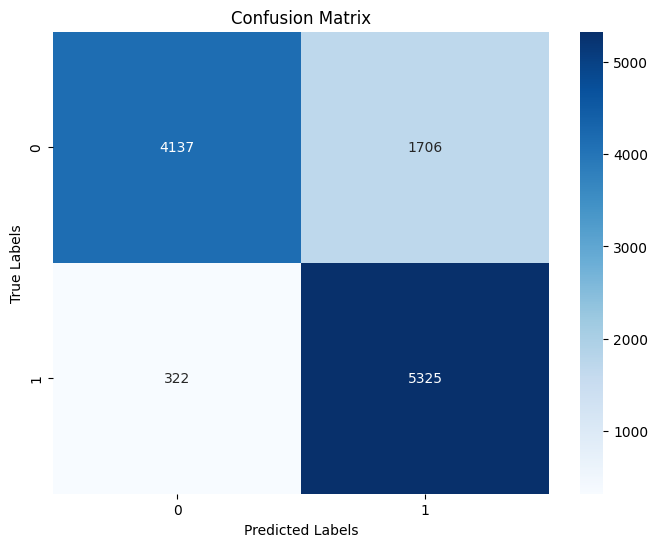

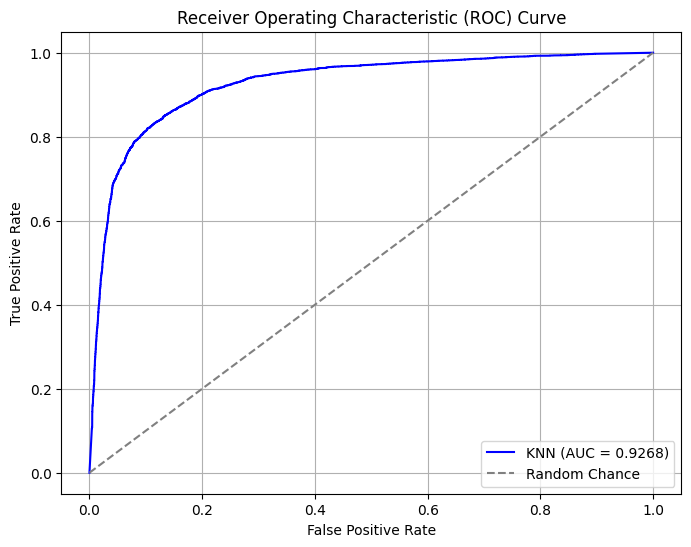

In [ ]:
# Initialize the KNN model with specified hyperparameters
knn = KNeighborsClassifier(n_neighbors=12, weights='distance', metric='euclidean')
#knn = KNeighborsClassifier(n_neighbors=5)

# Time the model fitting process
start_fit_time = time.time()
knn.fit(X_train_vectorized, y_train)
end_fit_time = time.time()

# Time the prediction process
start_predict_time = time.time()
knn_preds = knn.predict(X_test_vectorized)
knn_probs = knn.predict_proba(X_test_vectorized)[:, 1]  # Probabilities for ROC curve
end_predict_time = time.time()

# Print the time taken for fitting and prediction
fit_time = end_fit_time - start_fit_time
predict_time = end_predict_time - start_predict_time

print(f"Time taken for fitting the model: {fit_time:.4f} seconds")
print(f"Time taken for making predictions: {predict_time:.4f} seconds")

# Evaluate the model
accuracy = accuracy_score(y_test, knn_preds)
roc_auc = roc_auc_score(y_test, knn_probs)  # AUC-ROC

print(f"KNN Accuracy: {accuracy * 100:.2f}%")
print(f"KNN AUC-ROC: {roc_auc:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, knn_preds))

# Plot the confusion matrix
cm = confusion_matrix(y_test, knn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Plot the AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, knn_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

### Support Vector Machine

Time taken for fitting the model: 1.7048 seconds
Time taken for making predictions: 0.1975 seconds
SVC Accuracy: 85.03%
SVC AUC-ROC: 0.9153
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      5843
           1       0.86      0.83      0.84      5647

    accuracy                           0.85     11490
   macro avg       0.85      0.85      0.85     11490
weighted avg       0.85      0.85      0.85     11490



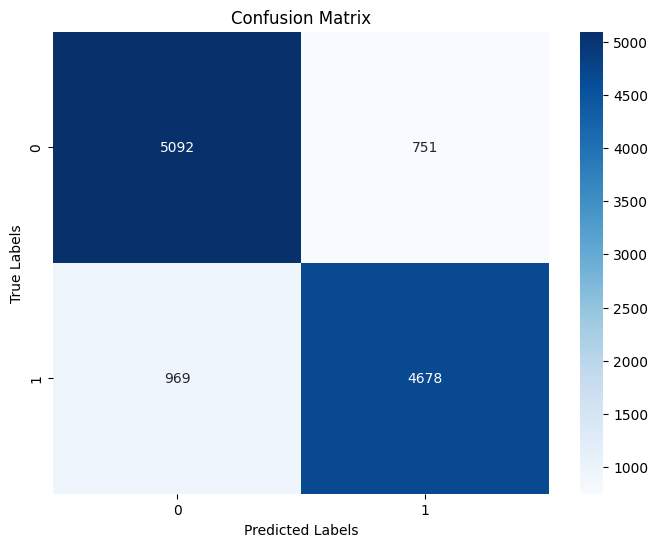

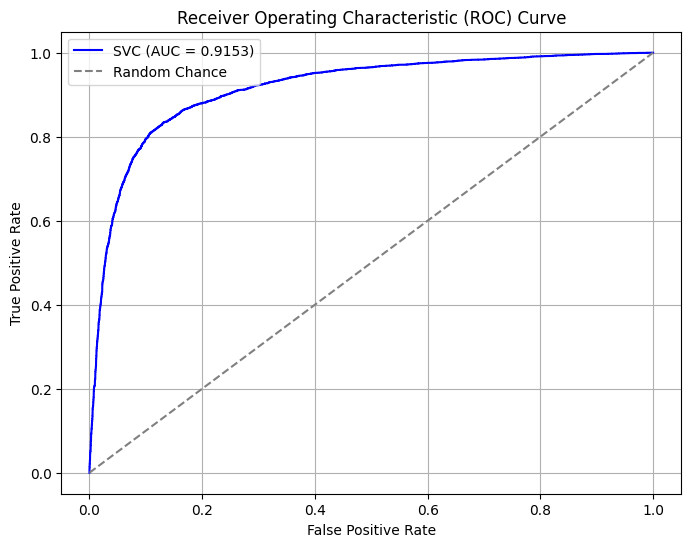

In [ ]:
# Initialize the LinearSVC model
svc = LinearSVC(random_state=42, C=0.1, max_iter=1000, tol=0.001)

# Time the model fitting process
start_fit_time = time.time()
svc.fit(X_train_vectorized, y_train)
end_fit_time = time.time()

# Time the prediction process
start_predict_time = time.time()
svc_preds = svc.predict(X_test_vectorized)
svc_decision_scores = svc.decision_function(X_test_vectorized)  # Decision scores for AUC-ROC
end_predict_time = time.time()

# Print the time taken for fitting and prediction
fit_time = end_fit_time - start_fit_time
predict_time = end_predict_time - start_predict_time

print(f"Time taken for fitting the model: {fit_time:.4f} seconds")
print(f"Time taken for making predictions: {predict_time:.4f} seconds")

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, svc_preds)
roc_auc = roc_auc_score(y_test, svc_decision_scores)  # AUC-ROC score

print(f"SVC Accuracy: {accuracy * 100:.2f}%")
print(f"SVC AUC-ROC: {roc_auc:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, svc_preds))

# Plot the confusion matrix
cm = confusion_matrix(y_test, svc_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Plot the AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, svc_decision_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVC (AUC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

### Logistic Regression

Time taken for fitting the model: 1.5218 seconds
Time taken for making predictions: 0.3267 seconds
LR Accuracy: 84.92%
LR AUC-ROC: 0.9148
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      5843
           1       0.86      0.83      0.84      5647

    accuracy                           0.85     11490
   macro avg       0.85      0.85      0.85     11490
weighted avg       0.85      0.85      0.85     11490



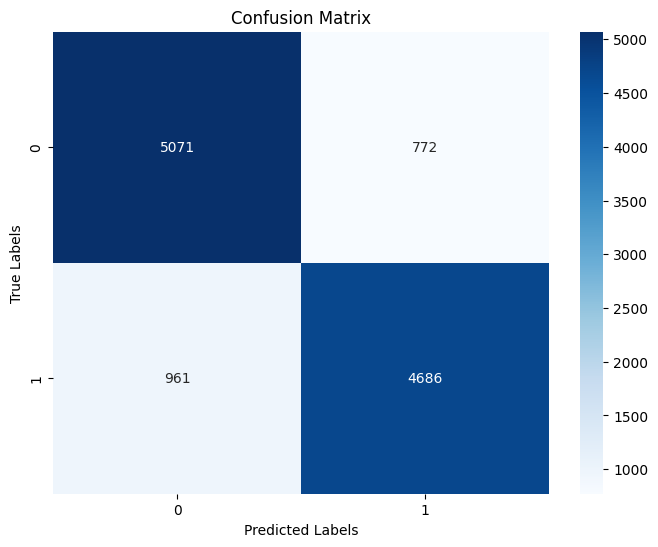

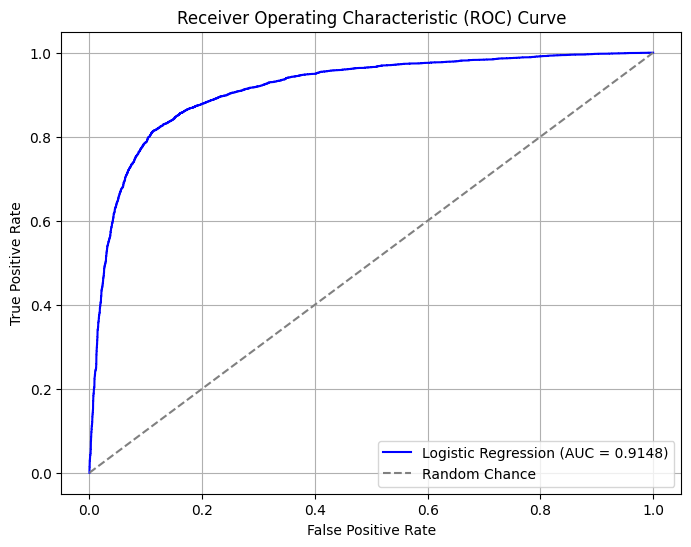

In [ ]:
# Initialize the Logistic Regression model with specific hyperparameters
lr = LogisticRegression(random_state=42, C=1, max_iter=100, penalty='l2', solver='liblinear')

# Time the model fitting process
start_fit_time = time.time()
lr.fit(X_train_vectorized, y_train)
end_fit_time = time.time()

# Time the prediction process
start_predict_time = time.time()
lr_preds = lr.predict(X_test_vectorized)
lr_probs = lr.predict_proba(X_test_vectorized)[:, 1]  # Probabilities for AUC-ROC
end_predict_time = time.time()

# Print the time taken for fitting and prediction
fit_time = end_fit_time - start_fit_time
predict_time = end_predict_time - start_predict_time

print(f"Time taken for fitting the model: {fit_time:.4f} seconds")
print(f"Time taken for making predictions: {predict_time:.4f} seconds")

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, lr_preds)
roc_auc = roc_auc_score(y_test, lr_probs)  # AUC-ROC score

print(f"LR Accuracy: {accuracy * 100:.2f}%")
print(f"LR AUC-ROC: {roc_auc:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, lr_preds))

# Plot the confusion matrix
cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Plot the AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

## Stacking KNN, SVM, and LR to Create Meta-Model

Time taken for fitting the model: 632.3453 seconds
Time taken for making predictions: 380.9210 seconds
Ensemble Accuracy (Stacking): 86.75%
Ensemble AUC-ROC: 0.9330
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      5843
           1       0.86      0.87      0.87      5647

    accuracy                           0.87     11490
   macro avg       0.87      0.87      0.87     11490
weighted avg       0.87      0.87      0.87     11490



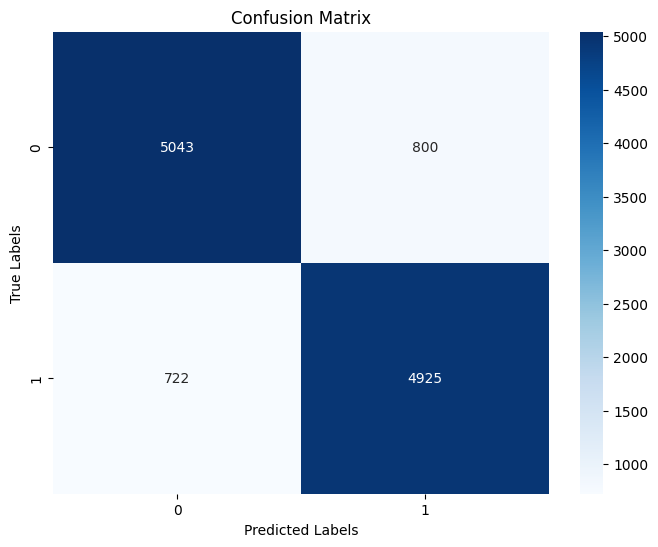

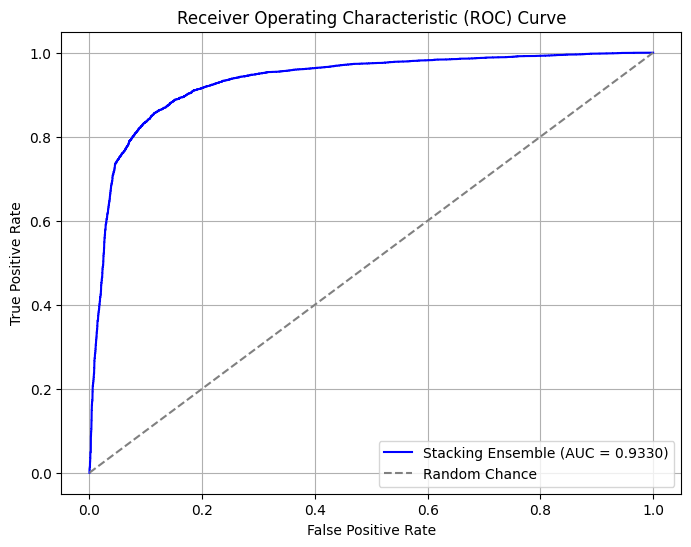

In [ ]:
# Stacking ensemble model initialization
stacking_clf = StackingClassifier(estimators=[
    ('knn', knn),
    ('svc', svc),
    ('lr', lr)],
    final_estimator=LogisticRegression())  # Meta-model

# Time the model fitting process
start_fit_time = time.time()
stacking_clf.fit(X_train_vectorized, y_train)
end_fit_time = time.time()

# Time the prediction process
start_predict_time = time.time()
stacking_preds = stacking_clf.predict(X_test_vectorized)
stacking_probs = stacking_clf.predict_proba(X_test_vectorized)[:, 1]  # Probabilities for AUC-ROC
end_predict_time = time.time()

# Print the time taken for fitting and prediction
fit_time = end_fit_time - start_fit_time
predict_time = end_predict_time - start_predict_time

print(f"Time taken for fitting the model: {fit_time:.4f} seconds")
print(f"Time taken for making predictions: {predict_time:.4f} seconds")

# Evaluate the ensemble model's accuracy
accuracy = accuracy_score(y_test, stacking_preds)
roc_auc = roc_auc_score(y_test, stacking_probs)  # AUC-ROC score

print(f"Ensemble Accuracy (Stacking): {accuracy * 100:.2f}%")
print(f"Ensemble AUC-ROC: {roc_auc:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, stacking_preds))

# Plot the confusion matrix
cm = confusion_matrix(y_test, stacking_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Plot the AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, stacking_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Stacking Ensemble (AUC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

## Deep Learning Model

In [ ]:
# Start timing tokenization process
start_tokenization_time = time.time()

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=5000)

# Fit tokenizer on the training data
tokenizer.fit_on_texts(X_train)

# Tokenize and pad the training and test data
X_train_tokenized = tokenizer.texts_to_sequences(X_train)
X_test_tokenized = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_tokenized = pad_sequences(X_train_tokenized, maxlen=100, padding='post', truncating='post')
X_test_tokenized = pad_sequences(X_test_tokenized, maxlen=100, padding='post', truncating='post')

# End timing tokenization process
end_tokenization_time = time.time()

# Calculate and print the time taken for tokenization
tokenization_time = end_tokenization_time - start_tokenization_time
print(f"Time taken for tokenization and padding: {tokenization_time:.4f} seconds")

Time taken for tokenization and padding: 3.0386 seconds


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 3/4
1437/1437 ━━━━━━━━━━━━━━━━━━━━ 104s 70ms/step - accuracy: 0.7075 - loss: 0.5231 - val_accuracy: 0.8487 - val_loss: 0.3684
Epoch 4/4
1437/1437 ━━━━━━━━━━━━━━━━━━━━ 144s 71ms/step - accuracy: 0.8770 - loss: 0.3164 - val_accuracy: 0.8547 - val_loss: 0.3528
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
Time taken for training: 287.8457 seconds
Time taken for prediction: 6.3976 seconds
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      5843
           1       0.84      0.87      0.86      5647

    accuracy                           0.85     11490
   macro avg       0.86      0.86      0.85     11490
weighted avg       0.86      0.85      0.85     11490



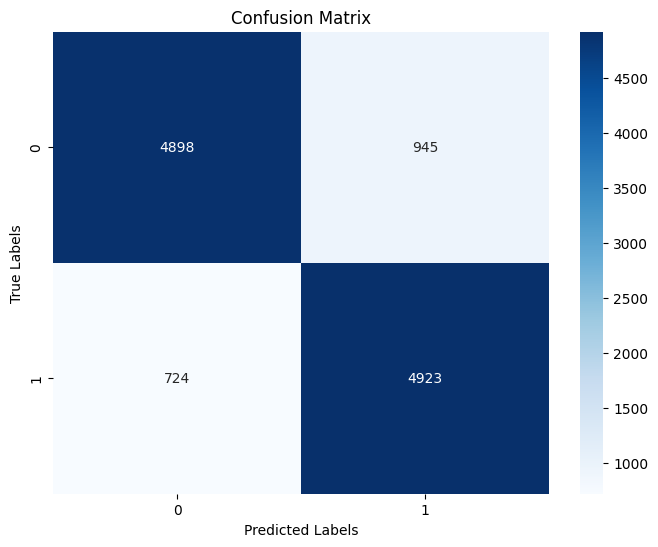

360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8546 - loss: 0.3511
CNN + LSTM Test Accuracy: 85.47%


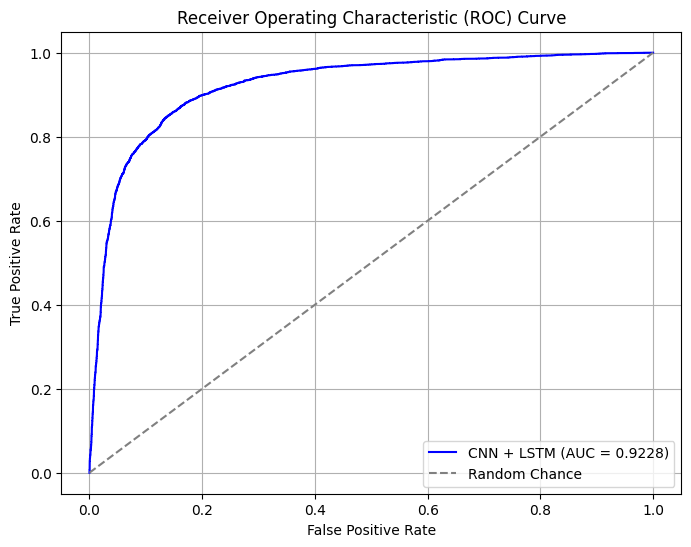

In [ ]:
# Define the Model (CNN + LSTM)
def create_model(input_shape, dropout_cnn=0.4, lstm_units=96, embedding_dim=250, dropout_lstm=0.2, dropout_dense=0.3, dense_units=128):
    model = tf.keras.Sequential()

    # Embedding Layer: Create embeddings for the input text
    model.add(tf.keras.layers.Embedding(input_dim=5000, output_dim=embedding_dim, input_length=input_shape[0]))

    # CNN Layer 1: Apply convolution to capture local dependencies
    model.add(tf.keras.layers.Conv1D(32, 5, activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(2))
    model.add(tf.keras.layers.Conv1D(64, 3, activation='relu'))
    model.add(tf.keras.layers.MaxPooling1D(2))
    model.add(tf.keras.layers.Dropout(dropout_cnn))

    # LSTM Layer: Capture sequential dependencies
    model.add(tf.keras.layers.LSTM(lstm_units, return_sequences=False))
    model.add(tf.keras.layers.Dropout(dropout_lstm))

    # Dense Layer for Classification
    model.add(tf.keras.layers.Dense(dense_units, activation='relu'))
    model.add(tf.keras.layers.Dropout(dropout_dense))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

    return model

# Create and compile the model
input_shape = (X_train_tokenized.shape[1],)
cnn_lstm_model = create_model(input_shape)

# Compile the model
cnn_lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# Time the training process
start_fit_time = time.time()
cnn_lstm_model.fit(X_train_tokenized, y_train, validation_data=(X_test_tokenized, y_test),
                   epochs=4, batch_size=32, initial_epoch=2)
end_fit_time = time.time()

# Time the prediction process
start_predict_time = time.time()
cnn_lstm_probs = cnn_lstm_model.predict(X_test_tokenized)  # Predict probabilities for AUC-ROC
cnn_lstm_preds = (cnn_lstm_probs > 0.5).astype(int)  # Convert probabilities to binary values
end_predict_time = time.time()

# Print the time taken for training and prediction
fit_time = end_fit_time - start_fit_time
predict_time = end_predict_time - start_predict_time
print(f"Time taken for training: {fit_time:.4f} seconds")
print(f"Time taken for prediction: {predict_time:.4f} seconds")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, cnn_lstm_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, cnn_lstm_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Evaluate the CNN + LSTM model
cnn_lstm_scores = cnn_lstm_model.evaluate(X_test_tokenized, y_test, verbose=1)
print(f"CNN + LSTM Test Accuracy: {cnn_lstm_scores[1] * 100:.2f}%")

# Calculate AUC-ROC and plot the curve
fpr, tpr, _ = roc_curve(y_test, cnn_lstm_probs)
roc_auc = roc_auc_score(y_test, cnn_lstm_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'CNN + LSTM (AUC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

## Combining Models

360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
Time taken to train (fit) the final meta-model: 0.0135 seconds
Time taken to make predictions: 0.0013 seconds
Final Stacked Model Accuracy: 86.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      5843
           1       0.86      0.86      0.86      5647

    accuracy                           0.86     11490
   macro avg       0.86      0.86      0.86     11490
weighted avg       0.86      0.86      0.86     11490



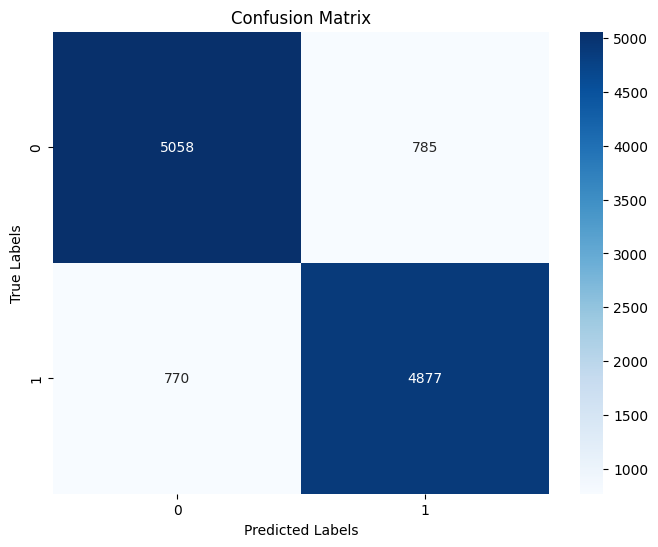

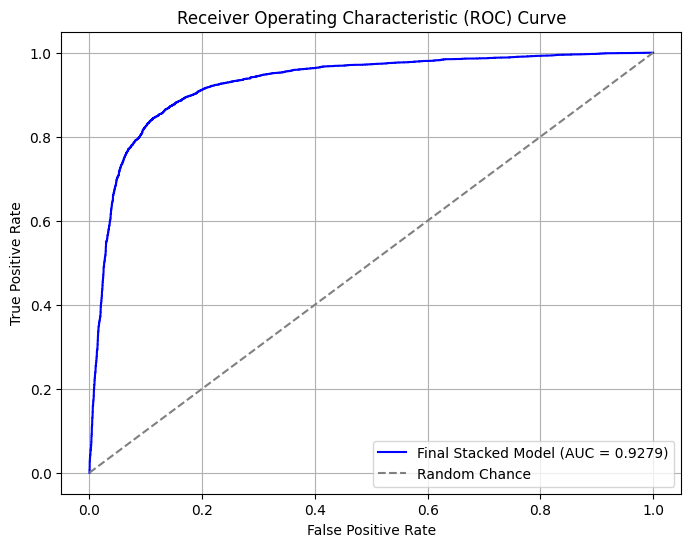


Total time for the entire process: 10.8871 seconds


In [ ]:
# Start timing the entire process
start_time = time.time()

# Get the predictions from the CNN + LSTM model
cnn_lstm_probs = cnn_lstm_model.predict(X_test_tokenized).flatten()  # Probabilities for AUC-ROC

# Stack the predictions from the stacking classifier and CNN + LSTM model
stacked_features = np.column_stack((stacking_preds, cnn_lstm_probs))

# Train the final meta-model (Logistic Regression)
final_meta_model = LogisticRegression()

# Start timing the fitting process
fit_start_time = time.time()
final_meta_model.fit(stacked_features, y_test)
fit_end_time = time.time()

# Time taken to fit the model
fit_time = fit_end_time - fit_start_time
print(f"Time taken to train (fit) the final meta-model: {fit_time:.4f} seconds")

# Evaluate Final Meta-Model
# Start timing the prediction process
predict_start_time = time.time()
final_probs = final_meta_model.predict_proba(stacked_features)[:, 1]  # Get probabilities for AUC-ROC
final_preds = (final_probs > 0.5).astype(int)  # Convert probabilities to binary predictions
predict_end_time = time.time()

# Time taken to make predictions
predict_time = predict_end_time - predict_start_time
print(f"Time taken to make predictions: {predict_time:.4f} seconds")

# Calculate and print the accuracy of the final meta-model
final_accuracy = accuracy_score(y_test, final_preds)
print(f"Final Stacked Model Accuracy: {final_accuracy * 100:.2f}%")

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, final_preds))

# Print the confusion matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Calculate and plot the AUC-ROC curve
fpr, tpr, _ = roc_curve(y_test, final_probs)
roc_auc = roc_auc_score(y_test, final_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Final Stacked Model (AUC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

# End the total time
end_time = time.time()
total_time = end_time - start_time
print(f"\nTotal time for the entire process: {total_time:.4f} seconds")

# Incorporation into Mock Reccomendation Algorithm

### Filter Out Misinformation

In [ ]:
def preprocess_content_with_meta_model(combined_df, final_meta_model, tokenizer, vectorizer, max_len=100):
    # Tokenize and pad for CNN + LSTM predictions
    X_tokenized = pad_sequences(tokenizer.texts_to_sequences(combined_df['text']), maxlen=max_len, padding='post', truncating='post')
    X_vectorized = vectorizer.transform(combined_df['text']).toarray()

    # Get model predictions
    cnn_preds = cnn_lstm_model.predict(X_tokenized).flatten()
    stacking_preds = stacking_clf.predict_proba(X_vectorized)[:, 1]  # Probability for positive class

    # Stack predictions for meta-model
    stacked_features = np.column_stack((stacking_preds, cnn_preds))

    # Filter reliable content using final meta-model
    reliable_content_df = combined_df[final_meta_model.predict(stacked_features) == 0].reset_index(drop=True)
    return reliable_content_df

### Create Mock Recommendation Model (for illustrative purposes - not rigorous)

In [ ]:
def recommend_content(filtered_df, recommendation_model):
    return recommendation_model.rank(filtered_df['text'].tolist())

class SimpleTwitterRecommendationModel:
    """
    A simplified version of Twitter's recommendation model that:
    1. Sources content from In-Network and Out-of-Network
    2. Scores content for ranking
    3. Filters content based on heuristics
    """
    def __init__(self, user_network, embedding_model):
        # user_network (dict): User's social graph with "following" and "followers".
        # embedding_model (object): Embedding-based similarity model.
        self.user_network = user_network
        self.embedding_model = embedding_model

    def fetch_candidates(self, user_id, content_df):
        # Fetch candidates from In-Network and Out-of-Network sources.
        # In-Network: Tweets from users the target user follows
        following = self.user_network.get(user_id, {}).get("following", [])
        in_network_candidates = content_df[content_df['author_id'].isin(following)]

        # Out-of-Network: Tweets similar to user's interests (using embeddings)
        user_embedding = self.embedding_model.get_user_embedding(user_id)
        content_embeddings = self.embedding_model.get_content_embeddings(content_df['text'])
        similarity_scores = self.embedding_model.calculate_similarity(user_embedding, content_embeddings)
        out_of_network_candidates = content_df.iloc[similarity_scores.argsort()[-500:]]  # Top 500

        return pd.concat([in_network_candidates, out_of_network_candidates])

    def rank_candidates(self, candidates_df):
        # Simulate a relevance score based on engagement likelihood (e.g., likes, retweets)
        candidates_df['relevance_score'] = (
            0.7 * candidates_df['like_count'] +
            0.2 * candidates_df['retweet_count'] +
            0.1 * candidates_df['reply_count']
        )
        return candidates_df.sort_values(by='relevance_score', ascending=False)

    def filter_candidates(self, ranked_df, user_preferences):
        # Apply basic heuristics and filters (e.g., author diversity)
        # Avoid too many tweets from the same author
        filtered_df = ranked_df.groupby('author_id').head(3).reset_index(drop=True)

        # Exclude blocked users or unwanted content based on user preferences
        blocked_users = user_preferences.get("blocked_users", [])
        unwanted_keywords = user_preferences.get("unwanted_keywords", [])
        filtered_df = filtered_df[
            ~filtered_df['author_id'].isin(blocked_users) &
            ~filtered_df['text'].str.contains('|'.join(unwanted_keywords), case=False, na=False)
        ]
        return filtered_df

    def rank(self, user_id, content_df, user_preferences):
        # Fetch, rank, and filter content for recommendation.
        Args:
            user_id (str): Target user ID.
            content_df (pd.DataFrame): DataFrame with content to recommend.
            user_preferences (dict): User preferences for filtering.

        Returns:
            list: Ranked list of recommended content.

        candidates = self.fetch_candidates(user_id, content_df)
        ranked_candidates = self.rank_candidates(candidates)
        filtered_candidates = self.filter_candidates(ranked_candidates, user_preferences)
        return filtered_candidates['text'].tolist()

### Hypothetical Model Use

In [ ]:
# User's social graph (simplified example)
user_network = {
    "user123": {
        "following": ["user456", "user789"],
        "followers": ["user999"]
    }
}

# Mock embedding model (would use actual embedding model not defined in this project)
embedding_model = MockEmbeddingModel()

# Initialize the recommendation model
recommendation_model = SimpleTwitterRecommendationModel(user_network, embedding_model)

# Filter misinformation using classifier
filtered_content_df = preprocess_content_with_meta_model(
    combined_test_df, final_meta_model, tokenizer, vectorizer, max_len=100
)

# # Generate recommendations from filtered content
# if not filtered_content_df.empty:
#     recommended_content = recommend_content(filtered_content_df, recommendation_model)

#     # Print recommended content
#     print("\nRecommended Content (Top 5):")
#     for i, content in enumerate(recommended_content[:5], 1):
#         print(f"{i}. {content}")
# else:
#     print("No reliable content available for recommendation.")